# PyTorch optimizers

An optimizer turns gradients into parameter updates. The gradient tells us the local direction of increase in the objective; the optimizer determines how much history, scaling, or noise is used when choosing the next step. PyTorch separates these concerns: a model stores parameters, `backward()` computes gradients, and an optimizer updates parameters after the gradients have been computed.

The comparison here uses a small quadratic objective so that the geometry can be inspected directly. The goal is not to declare one optimizer universally best. It is to see why the same learning rate can behave differently when the objective is steep in one direction and flat in another.


## An ill-conditioned quadratic

The objective is

```text
J(theta) = 1/2 theta^T A theta
A = diag(1, 25)
```

The minimum is at the origin. The second coordinate has twenty-five times the curvature of the first, so a step size large enough to move quickly along the flat direction can overshoot along the steep direction. This is the simplest setting in which optimizer trajectories become informative: the objective is convex and has a known answer, but its level sets are elongated.

The code constructs the objective in PyTorch and keeps the parameter tensor differentiable. The eigenvalues of `A` are also the curvature values that determine the shape of the contours.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)
A = torch.diag(torch.tensor([1.0, 100.0]))
initial = torch.tensor([8.0, 8.0])

def objective(theta):
    return 0.5 * theta @ A @ theta

print('initial objective:', objective(initial).item())


initial objective: 3232.0


## Optimizer state

Plain stochastic gradient descent uses the current gradient. Momentum maintains a velocity, so gradients from earlier steps continue to influence the direction of travel. Adam keeps running estimates of the first and second moments of the gradient and divides by an estimate of its scale. These mechanisms change the path, not the objective being minimized.

The runner below gives each optimizer the same starting point and the same number of updates. It records the parameter vector and objective value before each step. Keeping the starting point fixed is necessary for a meaningful comparison; otherwise a better-looking path could simply have received an easier initial condition.


In [2]:
def run_optimizer(optimizer_factory, steps=250):
    theta = initial.clone().requires_grad_()
    optimizer = optimizer_factory([theta])
    path = [theta.detach().clone()]
    losses = [objective(theta).item()]
    for _ in range(steps):
        optimizer.zero_grad()
        loss = objective(theta)
        loss.backward()
        optimizer.step()
        path.append(theta.detach().clone())
        losses.append(objective(theta).item())
    return torch.stack(path), torch.tensor(losses)

factories = {
    'SGD': lambda p: torch.optim.SGD(p, lr=0.01),
    'Momentum': lambda p: torch.optim.SGD(p, lr=0.005, momentum=0.9),
    'RMSProp': lambda p: torch.optim.RMSprop(p, lr=0.1, alpha=0.9),
    'Adam': lambda p: torch.optim.Adam(p, lr=0.1),
}
results = {}
for name, factory in factories.items():
    path, losses = run_optimizer(factory)
    results[name] = {'path': path, 'losses': losses}
    print(f'{name:9s} final theta={path[-1].numpy()}, objective={losses[-1]:.3e}')


SGD       final theta=[6.484679e-01 1.401298e-45], objective=2.103e-01
Momentum  final theta=[ 1.4007180e-05 -1.5744226e-05], objective=1.249e-08
RMSProp   final theta=[0.0467087  0.04670845], objective=1.102e-01
Adam      final theta=[-0.0005733 -0.0005733], objective=1.660e-05


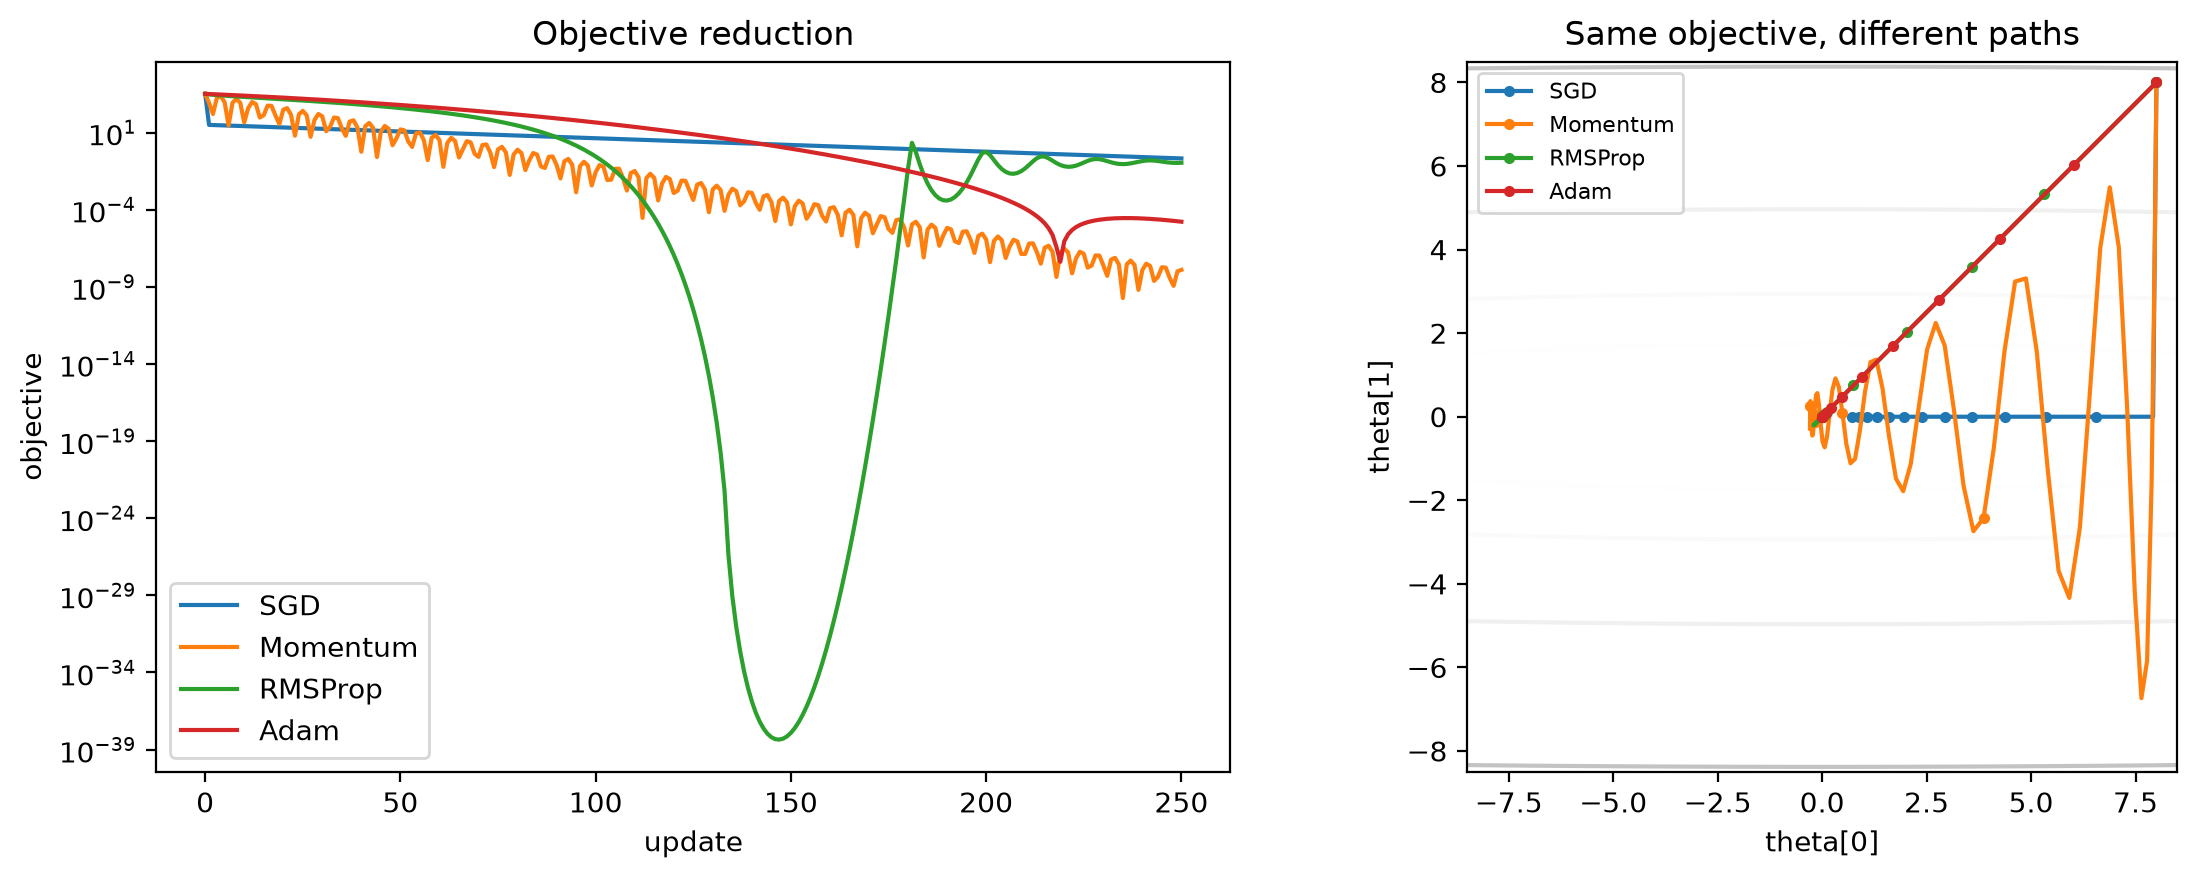

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, result in results.items():
    axes[0].plot(result['losses'].numpy(), label=name)
axes[0].set_yscale('log')
axes[0].set(xlabel='update', ylabel='objective', title='Objective reduction')
axes[0].legend()

grid = np.linspace(-8.5, 8.5, 250)
x1, x2 = np.meshgrid(grid, grid)
surface = 0.5 * (x1 ** 2 + 100 * x2 ** 2)
axes[1].contour(x1, x2, surface, levels=np.logspace(-1, 4, 12), cmap='Greys')
for name, result in results.items():
    path = result['path'].numpy()
    axes[1].plot(path[:, 0], path[:, 1], marker='o', markevery=20, ms=3, label=name)
axes[1].set(xlabel='theta[0]', ylabel='theta[1]', title='Same objective, different paths', aspect='equal')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Loss and parameter paths

The loss curves answer how quickly each method reduces the objective. The parameter paths answer a different question: how directly does it move through the geometry? A path that zigzags across a narrow valley can make progress while spending many updates correcting its previous direction. Momentum may cross the minimum before settling, while Adam can rescale the two coordinates differently because their gradient magnitudes differ.


## Static comparison of the trajectories

The contour plot shows the same parameter paths on the objective surface. The contours are level sets of the quadratic, so moving toward the center means reducing the loss. The comparison is deliberately small: it illustrates optimizer mechanics, not a benchmark. Learning rates, initialization, stopping time, and the conditioning of the objective all affect the result.


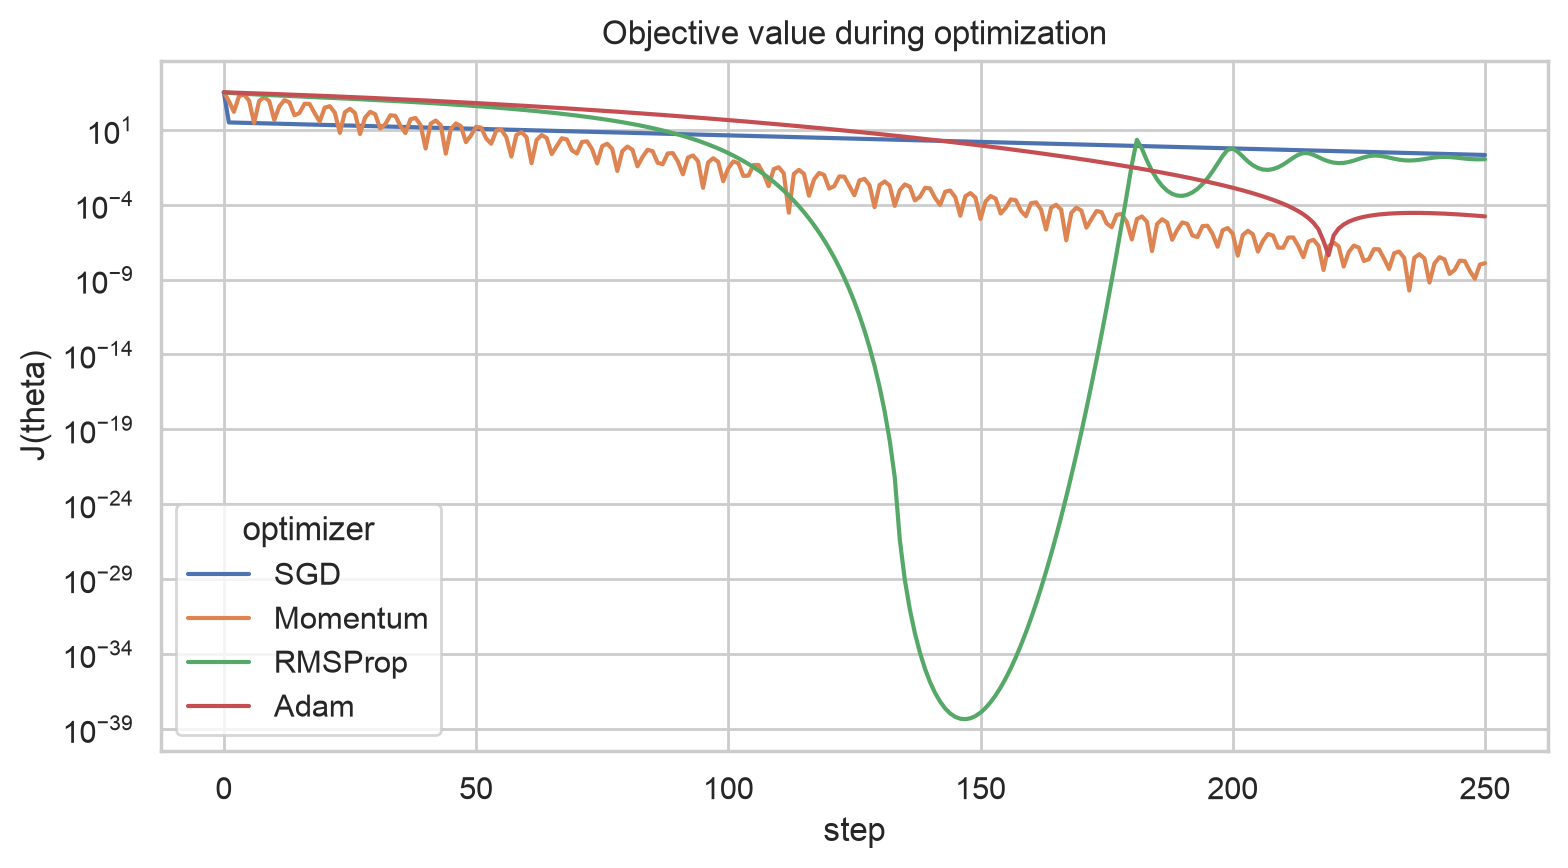

In [4]:
import pandas as pd
import seaborn as sns

records = []
for name, result in results.items():
    for step, loss in enumerate(result["losses"].numpy()):
        records.append({"optimizer": name, "step": step, "loss": loss})
loss_data = pd.DataFrame(records)

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=loss_data, x="step", y="loss", hue="optimizer", ax=ax)
ax.set(yscale="log", title="Objective value during optimization", ylabel="J(theta)")
fig.tight_layout()
plt.show()


## Limits of the comparison

On a real neural network, the objective is not a fixed quadratic and the gradient is usually computed from a minibatch. The local curvature can change during training, and the gradient estimate contains sampling noise. These optimizers are therefore useful update rules rather than guarantees of a particular trajectory. The controlled quadratic is a reference case for interpreting their state and behaviour.
